<a href="https://colab.research.google.com/github/sayim665/atml-pa0/blob/main/task1_resnet/task1_resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 — Inner Workings of ResNet-152

ATML PA0 — Task 1

Sections:
1. Baseline setup (pretrained ResNet-152, CIFAR-10 head, frozen backbone)
2. Residual connections ablation
3. Feature hierarchies (hooks + t-SNE/UMAP)
4. Transfer learning & generalization comparisons
5. (Optional) extra experiments

## Setup

In [ ]:
# !pip install -q torch torchvision scikit-learn umap-learn matplotlib tqdm

import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)

Using device: cuda


## Data — CIFAR-10

ResNet-152 expects 224x224 ImageNet-normalized inputs, so we resize + normalize CIFAR-10 (32x32) accordingly.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_set = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tf)
test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tf)


BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

classes = train_set.classes
print(classes)

100%|██████████| 170M/170M [19:46<00:00, 144kB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 1. Baseline Setup

In [ ]:
def build_resnet152(num_classes=10, freeze_backbone=True):
    model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)

model = build_resnet152(num_classes=10, freeze_backbone=True)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 161MB/s]


Trainable params: 20,490 / 58,164,298


In [ ]:
def train_head(model, loader, test_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, seen = 0.0, 0, 0
        for x, y in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            seen += x.size(0)

        train_loss = running_loss / seen
        train_acc = correct / seen
        val_acc = evaluate(model, test_loader)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

    return history


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, seen = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        correct += (out.argmax(1) == y).sum().item()
        seen += x.size(0)
    return correct / seen

In [ ]:

baseline_history = train_head(model, train_loader, test_loader, epochs=5)


Epoch 1/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 1: train_loss=0.4151 train_acc=0.8594 val_acc=0.8532


Epoch 2/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 2: train_loss=0.4067 train_acc=0.8617 val_acc=0.8531


Epoch 3/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 3: train_loss=0.4004 train_acc=0.8643 val_acc=0.8519


Epoch 4/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 4: train_loss=0.3933 train_acc=0.8655 val_acc=0.8537


Epoch 5/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 5: train_loss=0.3902 train_acc=0.8666 val_acc=0.8493


In [ ]:
import os
os.makedirs("results", exist_ok=True)

In [ ]:
torch.save(model.state_dict(), "results/baseline_resnet152_head.pt")

**Discussion prompt (write in report):** Why is it unnecessary/impractical to train ResNet-152 from scratch on a small dataset like CIFAR-10? What does the fact that a frozen backbone + linear head still works well tell us about feature transferability?

> ResNet-152 is a huge network with over 58 million parameters and networks this size are really only trained from scratch when there's a dataset like ImageNet backing them, with over a million images to learn from. That's what lets the model figure out low-level features such as edges, textures, and shapes on its own. CIFAR-10 only has 50,000 training images, which just isn't enough data (or worth the compute) to train something this large from zero.
In this baseline experiment, we froze the entire backbone and trained only a new linear head , 20,490/58,164,298 parameters. Despite this, the model reached 84.93% accuracy on CIFAR-10 after 5 epochs, a dataset with entirely different classes from ImageNet. This explains that the hierarchical features ReaNet-152 learned during ImageNet pretraining (edges, textures, shapes and object parts) are general enough to be directly reusable for a new classification task.

## 2. Residual Connections in Practice

In [ ]:
from torchvision.models.resnet import Bottleneck

for name, module in model.named_modules():
    if isinstance(module, Bottleneck):
        print(name)

layer1.0
layer1.1
layer1.2
layer2.0
layer2.1
layer2.2
layer2.3
layer2.4
layer2.5
layer2.6
layer2.7
layer3.0
layer3.1
layer3.2
layer3.3
layer3.4
layer3.5
layer3.6
layer3.7
layer3.8
layer3.9
layer3.10
layer3.11
layer3.12
layer3.13
layer3.14
layer3.15
layer3.16
layer3.17
layer3.18
layer3.19
layer3.20
layer3.21
layer3.22
layer3.23
layer3.24
layer3.25
layer3.26
layer3.27
layer3.28
layer3.29
layer3.30
layer3.31
layer3.32
layer3.33
layer3.34
layer3.35
layer4.0
layer4.1
layer4.2


In [ ]:


from torchvision.models.resnet import Bottleneck

def forward_no_skip(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    out = self.relu(out)
    return out


def disable_skip_connections(model, block_names):
    """block_names e.g. ['layer3.0', 'layer3.1'] — pick a FEW blocks, not all,
    otherwise very deep ResNet-152 likely won't train at all (that's expected
    and worth noting in the report if you try it)."""
    for name, module in model.named_modules():
        if name in block_names and isinstance(module, Bottleneck):
            module.forward = forward_no_skip.__get__(module, Bottleneck)
    return model


ablated_model = build_resnet152(num_classes=10, freeze_backbone=True)
ablated_model = disable_skip_connections(ablated_model, block_names=["layer3.0", "layer3.1"])  # TODO: adjust

ablated_history = train_head(ablated_model, train_loader, test_loader, epochs=5)

Epoch 1/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 1: train_loss=2.2460 train_acc=0.1615 val_acc=0.1795


Epoch 2/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 2: train_loss=2.2014 train_acc=0.1870 val_acc=0.1872


Epoch 3/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 3: train_loss=2.1887 train_acc=0.1906 val_acc=0.1897


Epoch 4/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 4: train_loss=2.1848 train_acc=0.1931 val_acc=0.1912


Epoch 5/5:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 5: train_loss=2.1796 train_acc=0.1976 val_acc=0.1970


In [ ]:
import os
os.makedirs("../figures", exist_ok=True)

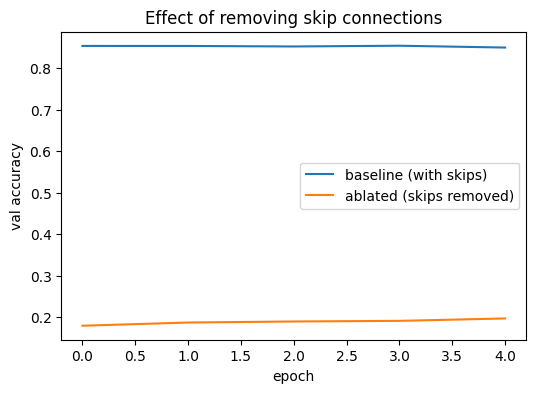

In [ ]:
# Plot baseline vs ablated training dynamics
plt.figure(figsize=(6,4))
plt.plot(baseline_history["val_acc"], label="baseline (with skips)")
plt.plot(ablated_history["val_acc"], label="ablated (skips removed)")
plt.xlabel("epoch"); plt.ylabel("val accuracy"); plt.legend(); plt.title("Effect of removing skip connections")
plt.savefig("../figures/task1_skip_connection_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Feature Hierarchies and Representations

In [ ]:
activations = {}

def get_hook(name):
    def hook(module, inp, out):
        activations[name] = out.detach()
    return hook


hook_layers = {
    "early": "layer1",
    "middle": "layer3",
    "late": "layer4",
}

handles = []
for tag, layer_name in hook_layers.items():
    layer = dict(model.named_modules())[layer_name]
    handles.append(layer.register_forward_hook(get_hook(tag)))

model.eval()
feats = {"early": [], "middle": [], "late": []}
labels_collected = []

with torch.no_grad():
    for i, (x, y) in enumerate(test_loader):
        x = x.to(device)
        _ = model(x)
        for tag in feats:
            pooled = activations[tag].mean(dim=[2, 3])  # global-average-pool spatial dims
            feats[tag].append(pooled.cpu().numpy())
        labels_collected.append(y.numpy())
        if i >= 15:  # cap for speed — ~1000 samples is plenty for t-SNE
            break

for h in handles:
    h.remove()

for tag in feats:
    feats[tag] = np.concatenate(feats[tag], axis=0)
labels_collected = np.concatenate(labels_collected, axis=0)

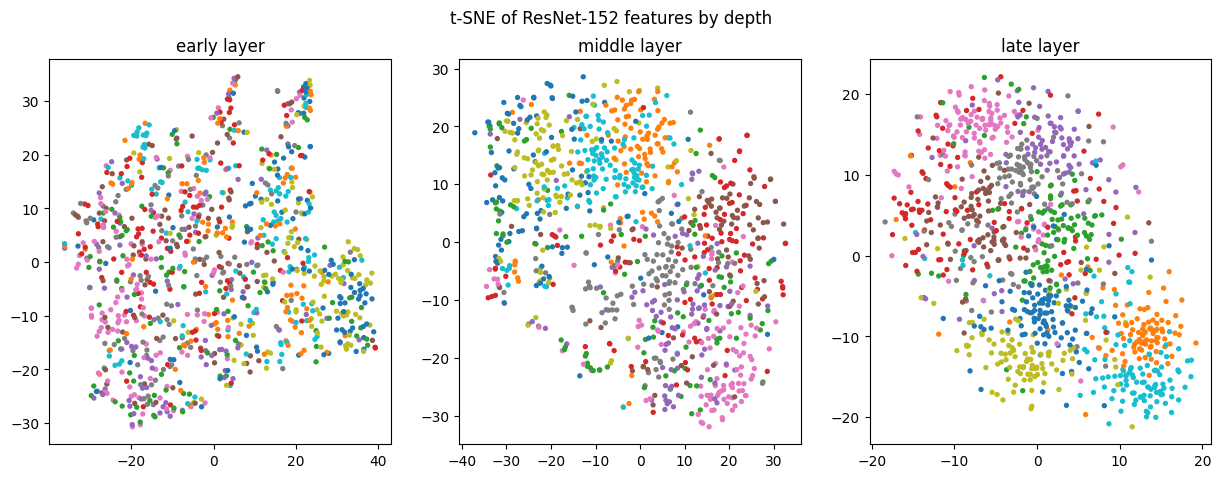

In [ ]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, tag in zip(axes, ["early", "middle", "late"]):
    emb = TSNE(n_components=2, init="pca", random_state=0).fit_transform(feats[tag])
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=labels_collected, cmap="tab10", s=8)
    ax.set_title(f"{tag} layer")
plt.suptitle("t-SNE of ResNet-152 features by depth")
plt.savefig("../figures/task1_feature_hierarchy_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

**Discussion prompt:** How does class separability evolve across layers? What differences do you see between low-level and high-level representations?

> Looking at the three plots, theres a clear progression as you go deeper into the network. In early layer, the points are basically a scattered mess with colors all mixed together with no clear grouping, which makes sense since this stage of the network is just picking up on generic stuff like edges ,colors and simple textures that show up in pretty much every image, regardless of what class it belongs to. By the middle layer we can see some loose clumping happening, then in the late layer, the seperation is much more obvious, you can actually pick out distinct groups now.
This tracks with how CNNs generally work, the early layers extract low level features, while the deeper layers combine those into higher-level, more abstract features that actually correspond to object identity.

## 4. Transfer Learning and Generalization

In [ ]:
# (a) pretrained-init vs random-init
model_pretrained = build_resnet152(num_classes=10, freeze_backbone=False)  # full fine-tune, pretrained weights

model_random = models.resnet152(weights=None)  # random init, no ImageNet weights
model_random.fc = nn.Linear(model_random.fc.in_features, 10)
model_random = model_random.to(device)

In [ ]:
from torch.utils.data import Subset
import numpy as np

subset_size = 5000  # ~10% of CIFAR-10 train set
rng = np.random.default_rng(0)
subset_indices = rng.choice(len(train_set), size=subset_size, replace=False)
train_subset = Subset(train_set, subset_indices)
train_subset_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [ ]:
history_pretrained = train_head(model_pretrained, train_subset_loader, test_loader, epochs=3, lr=1e-4)

Epoch 1/3:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1: train_loss=1.0285 train_acc=0.7198 val_acc=0.9103


Epoch 2/3:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2: train_loss=0.1703 train_acc=0.9428 val_acc=0.9359


Epoch 3/3:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3: train_loss=0.0862 train_acc=0.9734 val_acc=0.9406


In [ ]:
history_random = train_head(model_random, train_subset_loader, test_loader, epochs=3, lr=1e-4)

Epoch 1/3:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1: train_loss=2.2677 train_acc=0.1598 val_acc=0.1900


Epoch 2/3:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2: train_loss=2.0582 train_acc=0.2406 val_acc=0.2256


Epoch 3/3:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3: train_loss=1.9558 train_acc=0.2714 val_acc=0.2670


In [ ]:



def build_resnet152_finetune_last_block(num_classes=10):
    model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.layer4.parameters():  # unfreeze only the last residual stage
        p.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    for p in model.fc.parameters():
        p.requires_grad = True
    return model.to(device)



In [ ]:
model_last_block = build_resnet152_finetune_last_block(num_classes=10)
history_last_block = train_head(model_last_block, train_subset_loader, test_loader, epochs=3, lr=1e-4)

Epoch 1/3:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1: train_loss=1.4247 train_acc=0.6038 val_acc=0.8187


Epoch 2/3:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2: train_loss=0.5132 train_acc=0.8410 val_acc=0.8476


Epoch 3/3:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3: train_loss=0.3169 train_acc=0.9012 val_acc=0.8548


**Discussion prompt:** Which setting gives the best trade-off between compute and accuracy? Which layers seem most transferable across datasets, and why?

> Looking at all four setups together, the last block configuration really stands out as the sweet spot. It got basically the same accuracy as the head-only basline around 85%, but did it in a fraction of time (under a minute per epoch compared to roughly 8.5 minutes for the head only run), and on top of that, it used a much smaller subset of data (5000 images instead of the full 50,000). Full fine tuning of the pretrained model did reach the highest accuracy overall at 94.1%, but that came at a real cost: all 58 million parameters had to be updated, and each epoch took noticeably longer that the last block setup, even with far less training data involved.
This lines up well what we saw earlier in the feature hierarchy plot (Section 3/4): the early and middle layers weren't doing much in the way of class specific work. It was the fourth layer where features started becoming meaningfully class discriminative. So it makes sense that unfreezing just layer 4 recovers almost all the accuracy you'd get from fine tuning the entire network. Following that logic, the earlier layers (layers 1 through layer 3) end up being most transferable across datasets while layer 4 is least transferable, since it's the part of the network that actually needs to adapt the new task.

## 5. Optional Experiments

(t-SNE vs UMAP comparison, confused-class analysis, ResNet-152 vs ResNet-18 features — attempt only if time permits after Tasks 2-4 are on track.)